## Import libraries


In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("phantrntngvyk64cntt/processed-rsitmd-256-clean")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'processed-rsitmd-256-clean' dataset.
Path to dataset files: /kaggle/input/processed-rsitmd-256-clean


## Load and prepare data

In [10]:
import os
import time
import numpy as np
import tensorflow as tf
import kagglehub
from datasets import load_from_disk
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# STEP 1: LOAD AND PREPARE DATA
# ==========================================

hf_dataset = load_from_disk(path)

# Extract class information
try:
    # This works if it was saved as a ClassLabel
    class_names = hf_dataset['train'].features['label'].names
except AttributeError:
    # This acts as a fallback if it was saved as a generic Value
    # We ask the dataset to find all unique labels in the training set
    unique_labels = hf_dataset['train'].unique('label')
    class_names = [str(label) for label in sorted(unique_labels)]

num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")
# Create a lookup layer to convert string labels (words) into integer indices (0, 1, 2...)
# We use the class_names list you extracted earlier!
# You can delete or comment out the label_encoder line entirely!
# label_encoder = tf.keras.layers.StringLookup(...)

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

def preprocess_for_tf(image, label):
    # Resize and format the image
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    # The label is ALREADY a number, so we just make sure it's the right integer type
    label = tf.cast(label, tf.int32)

    return image, label

print("Converting to TensorFlow datasets...")
train_dataset = hf_dataset["train"].to_tf_dataset(
    columns=["image"], label_cols=["label"], batch_size=BATCH_SIZE, shuffle=True
)
train_dataset = train_dataset.map(preprocess_for_tf, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

validation_dataset = hf_dataset["validation"].to_tf_dataset(
    columns=["image"], label_cols=["label"], batch_size=BATCH_SIZE, shuffle=False
)
validation_dataset = validation_dataset.map(preprocess_for_tf, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

Found 33 classes: ['airport', 'bareland', 'baseballfield', 'beach', 'boat', 'bridge', 'center', 'church', 'commercial', 'denseresidential', 'desert', 'farmland', 'forest', 'industrial', 'intersection', 'meadow', 'mediumresidential', 'mountain', 'park', 'parking', 'plane', 'playground', 'pond', 'port', 'railwaystation', 'resort', 'river', 'school', 'sparseresidential', 'square', 'stadium', 'storagetanks', 'viaduct']
Converting to TensorFlow datasets...


##  Build the model

In [11]:
# ==========================================
# STEP 2: BUILD THE MODEL
# ==========================================
print("Building ResNet50 Model...")
base_model = ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base layers

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

Building ResNet50 Model...


## Training

In [12]:
# ==========================================
# STEP 3: TRAIN WITH CHECKPOINTS
# ==========================================
EPOCHS = 10

# 1. Create the Checkpoint rules
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_resnet50_model.keras', # The name of the file to save
    monitor='val_accuracy',               # We want it to watch the validation accuracy
    save_best_only=True,                  # ONLY save if it beats the previous high score!
    mode='max',                           # We want the accuracy to go up (maximum)
    verbose=1                             # Print a message when it saves
)

print(f"Starting training for {EPOCHS} epochs...")
start_time = time.time()

# 2. Add the callback to the training loop
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint_callback]       # <--- Pass the checkpoint here!
)

end_time = time.time()
print(f"Training finished in {end_time - start_time:.2f} seconds.")

Starting training for 10 epochs...
Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.4530 - loss: 2.1078
Epoch 1: val_accuracy improved from None to 0.82453, saving model to best_resnet50_model.keras

Epoch 1: finished saving model to best_resnet50_model.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 62s 420ms/step - accuracy: 0.6647 - loss: 1.2614 - val_accuracy: 0.8245 - val_loss: 0.6047
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.8846 - loss: 0.4069
Epoch 2: val_accuracy improved from 0.82453 to 0.86180, saving model to best_resnet50_model.keras

Epoch 2: finished saving model to best_resnet50_model.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 34s 295ms/step - accuracy: 0.9004 - loss: 0.3636 - val_accuracy: 0.8618 - val_loss: 0.4911
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.9513 - loss: 0.2217
Epoch 3: val_accuracy improved from 0.86180 to 0.87112, saving model to best_resnet50_model.keras

Epoch 3: finished saving model to best_resnet50

## Evauate & generate merrics

In [13]:
# ==========================================
# STEP 4: EVALUATE AND GENERATE METRICS
# ==========================================
print("Generating predictions on validation set for reporting...")

y_true = []
y_pred_probs = []

# Iterate through the validation dataset to get true labels and predictions
for images, labels in validation_dataset:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
# Convert probabilities to actual class predictions (0, 1, 2, etc.)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

# Calculate metrics using scikit-learn
acc = accuracy_score(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)
class_report_str = classification_report(y_true, y_pred, target_names=class_names)

Generating predictions on validation set for reporting...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Reporting


FINAL TRAINING REPORT
Total Training Time: 368.76 seconds
Average Epoch Time:  36.88 seconds
----------------------------------------
Overall Accuracy:    0.8742
Balanced Accuracy:   0.8166
----------------------------------------
Classification Report (includes Macro/Micro metrics per class):
                   precision    recall  f1-score   support

          airport       0.67      0.89      0.76        18
         bareland       0.75      0.75      0.75         8
    baseballfield       1.00      0.86      0.92        14
            beach       0.88      1.00      0.93        21
             boat       0.00      0.00      0.00         2
           bridge       0.95      0.86      0.90        21
           center       0.78      0.70      0.74        20
           church       0.79      1.00      0.88        19
       commercial       0.75      0.90      0.82        20
 denseresidential       0.91      1.00      0.95        21
           desert       1.00      1.00      1.00      

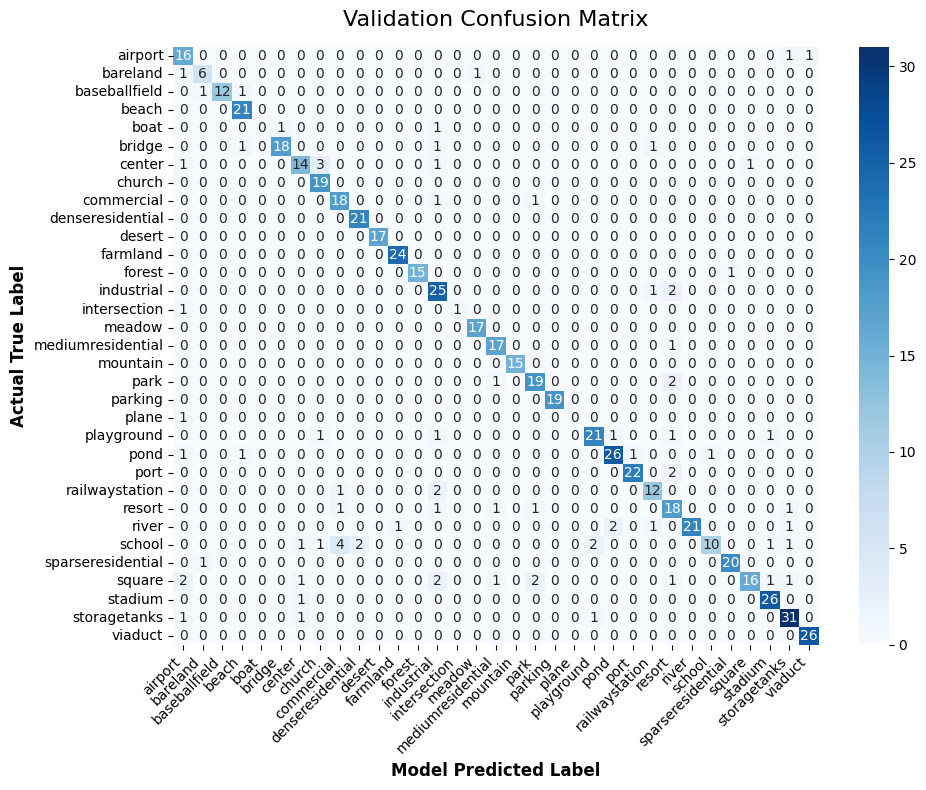

In [17]:
# ==========================================
# STEP 5: REPORT METRICS
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

total_train_time_sec = end_time - start_time
avg_epoch_time_sec = total_train_time_sec / EPOCHS
print("\n" + "="*40)
print("FINAL TRAINING REPORT")
print("="*40)
print(f"Total Training Time: {total_train_time_sec:.2f} seconds")
print(f"Average Epoch Time:  {avg_epoch_time_sec:.2f} seconds")
print("-" * 40)
print(f"Overall Accuracy:    {acc:.4f}")
print(f"Balanced Accuracy:   {balanced_acc:.4f}")
print("-" * 40)
print("Classification Report (includes Macro/Micro metrics per class):")
print(class_report_str)

print("Gathering data for the confusion matrix...")

# 1. Extract the actual true labels from the validation dataset
# We loop through the dataset batches and glue all the labels together
y_true = np.concatenate([y.numpy() for x, y in validation_dataset], axis=0)

# 2. Get the model's predictions
# The model outputs a list of probabilities for each image
predictions = model.predict(validation_dataset)

# Convert those probabilities into the single highest predicted class index (0, 1, 2...)
y_pred = np.argmax(predictions, axis=1)

# 3. Calculate the raw confusion matrix numbers
cm = confusion_matrix(y_true, y_pred)

# 4. Plot the matrix visually using Seaborn
plt.figure(figsize=(10, 8))

# Create a heatmap. 'annot=True' puts the numbers inside the boxes.
# 'fmt='d'' ensures the numbers are displayed as plain integers.
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Validation Confusion Matrix', fontsize=16, pad=15)
plt.ylabel('Actual True Label', fontsize=12, fontweight='bold')
plt.xlabel('Model Predicted Label', fontsize=12, fontweight='bold')

# Rotate the x-axis labels so the disease names don't overlap
plt.xticks(rotation=45, ha='right')

# Adjust layout so everything fits on the screen neatly
plt.tight_layout()
plt.show()

## Testing

Running prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


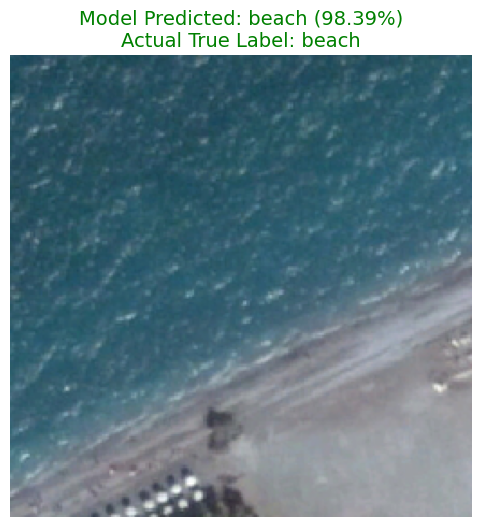

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Grab a single example from the validation set
# You can change the '0' to any other number to test different images
sample_index = 610
sample_example = hf_dataset['validation'][sample_index]

# Extract the raw image and the true INTEGER label
raw_image = sample_example['image']
true_label_index = sample_example['label']

# Convert the integer back to the human-readable string!
true_label_text = class_names[true_label_index]

# 2. Preprocess the image exactly like we did for training
img_tensor = tf.image.resize(raw_image, (224, 224))
img_tensor = tf.cast(img_tensor, tf.float32)

# Neural networks expect a "batch" of images, not just one.
# We use expand_dims to change the shape from (224, 224, 3) to (1, 224, 224, 3)
img_batch = tf.expand_dims(img_tensor, 0)

# 3. Make the prediction
print("Running prediction...")
predictions = model.predict(img_batch)

# The model outputs a list of probabilities for each class.
# We use argmax to find the index of the highest probability.
predicted_index = np.argmax(predictions[0])
predicted_probability = np.max(predictions[0]) * 100

# Map the predicted index back to the human-readable class name
predicted_class_name = class_names[predicted_index]

# 4. Display the image and the results
plt.figure(figsize=(6, 6))
plt.imshow(raw_image)
plt.title(
    f"Model Predicted: {predicted_class_name} ({predicted_probability:.2f}%)\n"
    f"Actual True Label: {true_label_text}",
    fontsize=14,
    color='green' if predicted_class_name == true_label_text else 'red'
)
plt.axis('off')
plt.show()




## Saliency map

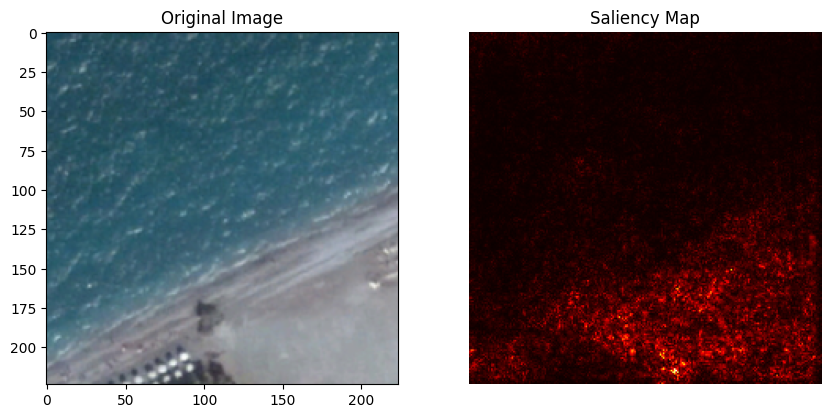

In [25]:
import matplotlib.pyplot as plt

def get_saliency_map(model, image, class_index):
    # Ensure the image is a tensor and we are watching it for gradients
    img_tensor = tf.convert_to_tensor(image)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        # Pass through the model
        predictions = model(img_tensor)
        # Get the prediction score for the specific class
        loss = predictions[:, class_index]

    # Calculate gradients of the loss with respect to the input image
    gradients = tape.gradient(loss, img_tensor)

    # Take the absolute value and maximum across color channels to get a 2D grayscale map
    saliency = tf.reduce_max(tf.abs(gradients), axis=-1)[0]

    return saliency.numpy()

# How to use it:
# (Assuming `img_batch` and `predicted_index` are from your previous single-image test)
saliency_map = get_saliency_map(model, img_batch, predicted_index)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img_batch[0] / 255.0) # Normalize for displaying

plt.subplot(1, 2, 2)
plt.title("Saliency Map")
plt.imshow(saliency_map, cmap='hot')
plt.axis('off')
plt.show()

## Grad-CAM

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_368']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


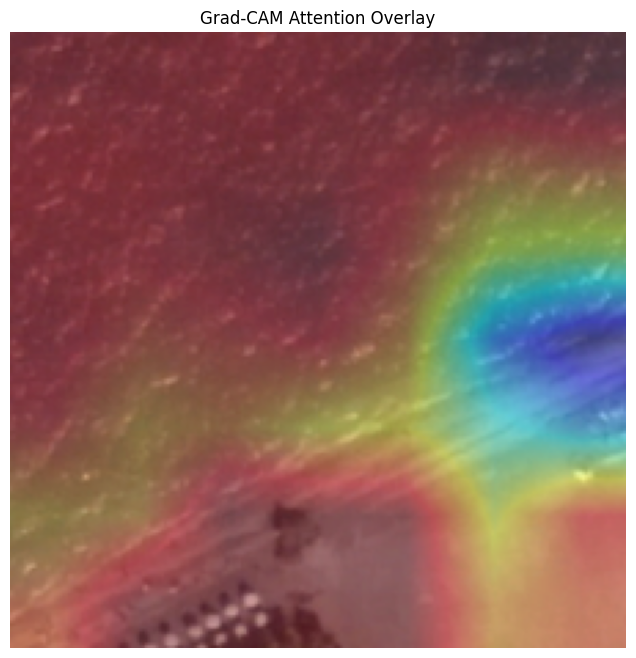

In [26]:
import cv2 # Make sure you have opencv-python installed (pip install opencv-python)
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, full_model, last_conv_layer_name="conv5_block3_out"):
    # 1. Safely locate the nested ResNet50 model and the top layers
    resnet_model = None
    pooling_layer = None
    dense_layer = None

    for layer in full_model.layers:
        if isinstance(layer, tf.keras.Model): # Identifies the ResNet50 base model
            resnet_model = layer
        elif isinstance(layer, tf.keras.layers.GlobalAveragePooling2D):
            pooling_layer = layer
        elif isinstance(layer, tf.keras.layers.Dense):
            dense_layer = layer

    # 2. Create a sub-model that outputs BOTH the target conv layer and the final ResNet output
    grad_model = tf.keras.models.Model(
        [resnet_model.inputs],
        [resnet_model.get_layer(last_conv_layer_name).output, resnet_model.output]
    )

    # 3. Track the gradients
    with tf.GradientTape() as tape:
        # Run preprocessing
        inputs = tf.keras.applications.resnet50.preprocess_input(img_array)

        # Pass inputs through the ResNet sub-model
        last_conv_layer_output, resnet_output = grad_model(inputs)

        # Crucial step: Watch the conv layer output to track its gradients
        tape.watch(last_conv_layer_output)

        # Pass the ResNet output through your final pooling and dense layers
        x = pooling_layer(resnet_output)
        preds = dense_layer(x)

        # Get the highest predicted class
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 4. Calculate gradients of the top class with respect to the feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Weigh the feature map by the gradients
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. Normalize the heatmap to values between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# ==========================================
# GENERATE AND DISPLAY THE OVERLAY
# ==========================================

# 1. Generate the heatmap
heatmap = make_gradcam_heatmap(img_batch, model)

# 2. Prepare the original image
# Note: we take the first image from the batch and ensure it is an 8-bit integer for cv2
img_to_show = (img_batch[0].numpy()).astype('uint8')

# 3. Resize heatmap to match the original image size
heatmap_resized = cv2.resize(heatmap, (img_to_show.shape[1], img_to_show.shape[0]))

# 4. Convert heatmap to RGB and apply a color map (JET creates the classic red-to-blue look)
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

# 5. Overlay the heatmap onto the original image (0.6 opacity for image, 0.4 for heatmap)
superimposed_img = cv2.addWeighted(img_to_show, 0.6, heatmap_colored, 0.4, 0)

# 6. Plot the result
plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.title("Grad-CAM Attention Overlay")
plt.axis('off')
plt.show()